Exercise 4: NumPy Array Operations (20 points)

In [17]:
import numpy as np
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing

arry = np.ones((5,5))
arry[1:4, 1:4] = 0
print(arry)

# Task 2: Normalize a random array
# (5 points)
#np.random.seed(42)
#random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1

np.random.seed(42)
data = np.random.randn(100,3)
mean = data.mean(axis=0) # axis =0 means calculating for each column
std = data.std(axis=0) 
normalized_data = (data - mean) / std
print(normalized_data)

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
'''X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
'''
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta 

# given data
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# transpose 
X_T = X.T
XtT = X_T @ X
# inverse
XtT_inv = np.linalg.inv(XtT)
# Theta estimate
theta_hat = XtT_inv @X_T @ y
print("Estimated theta:", theta_hat)
print("True theta:", true_theta)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

Exercise 5: Pandas Data Analysis (30 points)

In [18]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
# TODO: Identify and count missing values
# TODO: Fill missing exam_score with the mean score for the student's major
# TODO: Fill missing hours_studied with the median for the student's year

df.info()
df.describe()
df.head()
df.isnull().sum()
df['exam_score'] = df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'), inplace = True)
df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'), inplace = True) # When using inplace= True, the modified column is saved back to the original. So, we don't have to assign it back to the column. 

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
# TODO: Find the major with the highest average exam_score
# TODO: Calculate the correlation between hours_studied and exam_score
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

avr_exam_score_by_major = df.groupby('major')['exam_score'].mean()
print(avr_exam_score_by_major)

best_major = avr_exam_score_by_major.idxmax()
print("Best major:", best_major)

correlation = df['hours_studied'].corr(df['exam_score'])
print("correlation:", correlation)

# Creating a column using a function (or can use np.select)
def performance_category(score):
    if score > 90:
        return 'excellent'
    elif score >= 80:
        return 'good'
    elif score >= 70:
        return 'average'
    else:
        return 'needs improvement'
df['performance']= df['exam_score'].apply(performance_category)
print(df[['exam_score', 'performance']].head())

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)

major_year_stats = df.groupby(['major', 'year']).agg(
    number_of_students=('student_id', 'count'),
    average_exam_score=('exam_score', 'mean'),
    average_hours_studied=('hours_studied', 'mean')
)
print(major_year_stats)

cutoff = df['exam_score'].nlargest(5).min() # This gives the minimum score among the top 5 scores. 
top_5_students = df[df['exam_score'] >= cutoff] # This gives all students whose score is above the cutoff point. 
print(top_5_students)

pivot_table = pd.pivot_table(df, values ='exam_score', index ='major', columns = 'year', aggfunc= 'mean') # The 'aggfunc' handles multiple values by taking the mean of them.
print(pivot_table)


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Best major: CS
correlation: -0.05679962900286857
   exam_score        performance
0   68.199753  needs improvement
1   77.322537            average
2   77.930725            average
3   67.856486  needs improvement
4   93.657745          excellent
              number_of_students  average_exam_score 

C:\Users\seben\AppData\Local\Temp\ipykernel_22236\2771954212.py:38: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['exam_score'] = df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'), inplace = True)
C:\Users\seben\AppData\Local\Temp\ipykernel_22236\2771954212.py:39: ChainedAssignmentError: A value is being 

Exercise 6: Data Visualization (25 points)

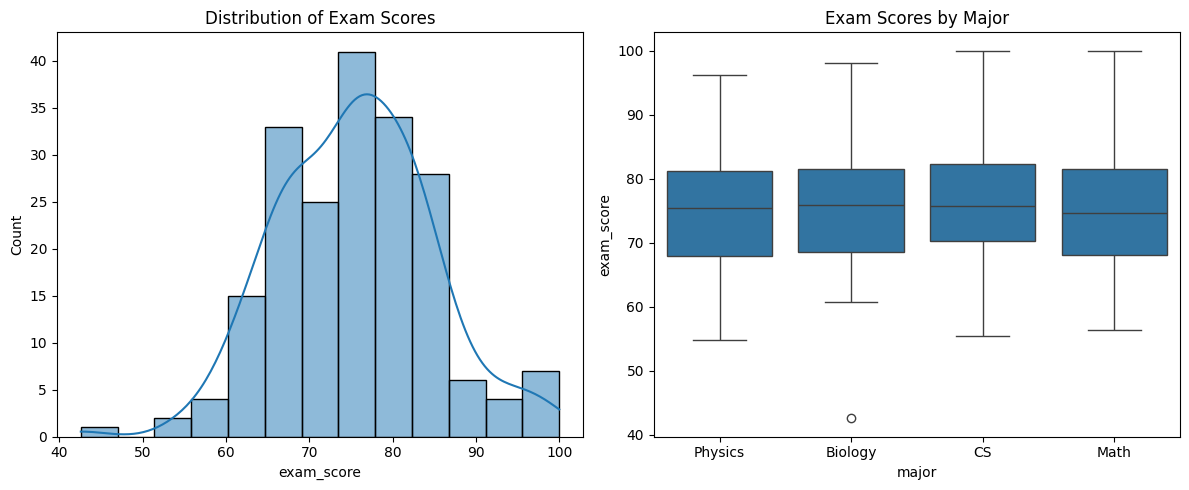

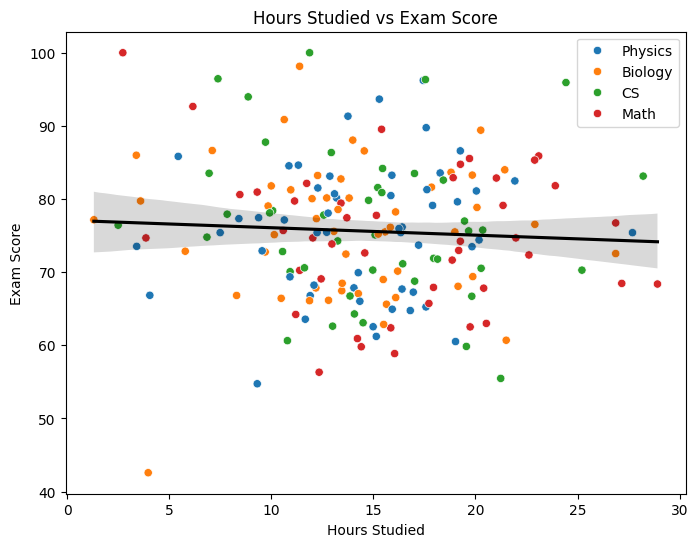

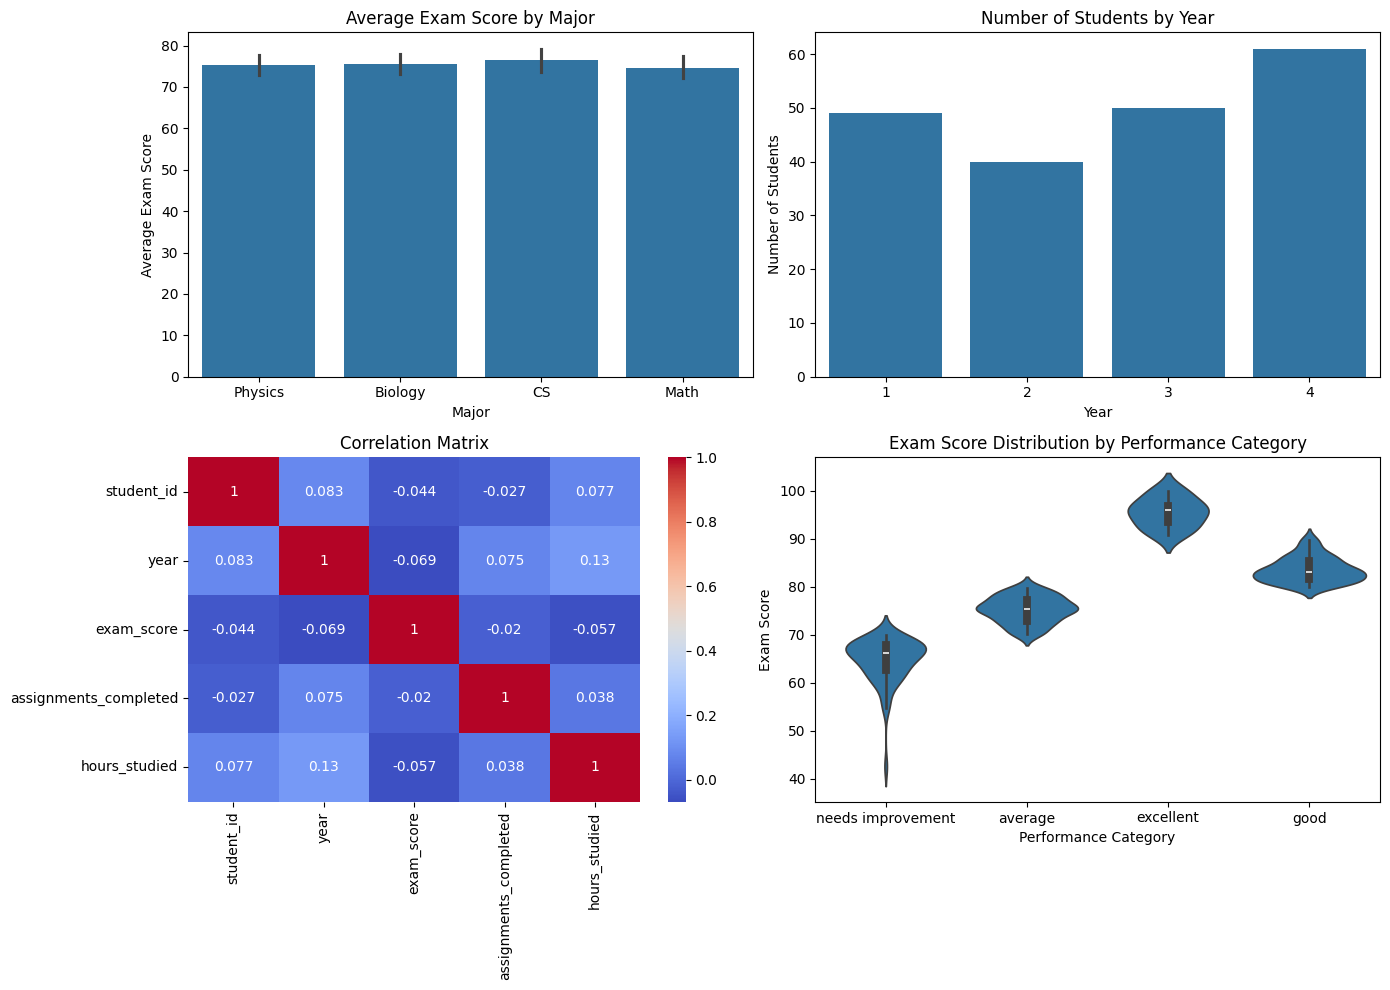

In [20]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5)) # this creates 2 subplots named ax1 and ax2. 

# Left: Hisrtogram with KDE
sns.histplot(df['exam_score'], kde= True, ax= ax1)
ax1.set_title('Distribution of Exam Scores')

#Right: Box plot of exam scores by major
sns.boxplot(x='major', y='exam_score', data=df, ax=ax2)
ax2.set_title('Exam Scores by Major')
plt.tight_layout()
plt.show()


# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels

plt.figure(figsize=(8,6))
sns.scatterplot(x='hours_studied', y='exam_score', hue='major', data=df)
sns.regplot(x='hours_studied', y='exam_score', scatter= False, color = 'black',data= df) # scatter = False means to plot a line(aggregated plot) rather than a data points. 
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()


# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability

fig, axes = plt.subplots(2,2,figsize=(14, 10))

# Bar chart: Average exam score by major
sns.barplot(data=df, x='major', y='exam_score', ax=axes[0,0])
axes[0,0].set_title('Average Exam Score by Major')
axes[0,0].set_xlabel('Major')
axes[0,0].set_ylabel('Average Exam Score')

# Count plot: Number of students by year
sns.countplot(data=df, x='year', ax=axes[0,1])
axes[0,1].set_title('Number of Students by Year')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Number of Students')

# Heat map: Correlation matrix of numerical columns
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot= True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Correlation Matrix')

# Violin plot: Exam score distribution by performance category
sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1,1])
axes[1,1].set_title('Exam Score Distribution by Performance Category')
axes[1,1].set_xlabel('Performance Category')
axes[1,1].set_ylabel('Exam Score')
plt.tight_layout()
plt.show()





Exercise 7: Integration Challenge (25 points)

           Number_of_Customers  Average_Income  Average_CLV      Total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683
top customers:      age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   
423   43  34443.666248                   6          173.245130    0

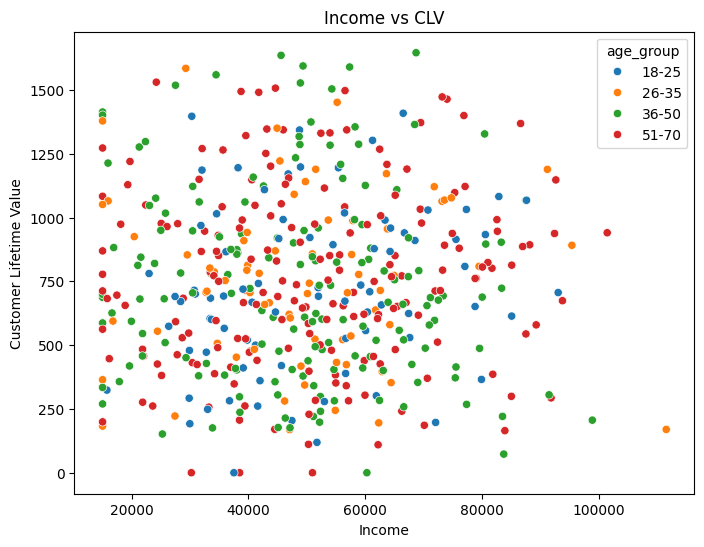

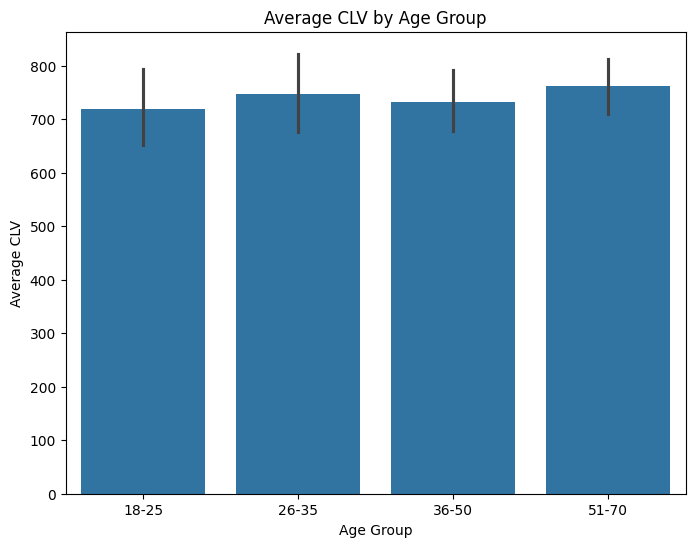

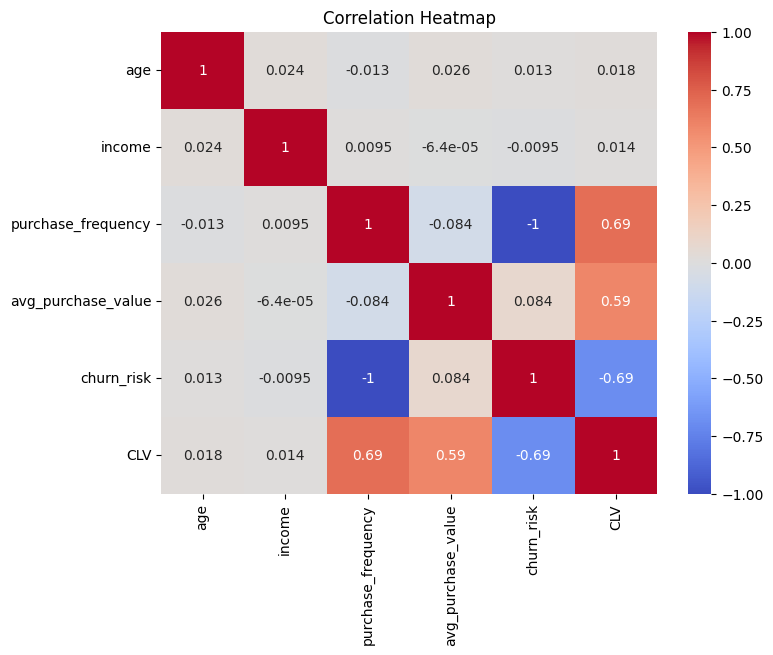

In [21]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)


# Find max purchasing frequency
max_frequency = customers['purchase_frequency'].max()

# Calculate churn risk
customers['churn_risk']= 1- (customers['purchase_frequency']/ max_frequency)

# Calculate CLV
customers['CLV'] = (customers['purchase_frequency']* customers['avg_purchase_value'] *(1+customers['churn_risk']))
customers.head()


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70

values=[18,25,35,50,70]
labels =['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=values, labels= labels, include_lowest = True)
customers.head()

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV

age_summary = customers.groupby('age_group').agg(
     Number_of_Customers=('age', 'count'), 
     Average_Income=('income', 'mean'), 
     Average_CLV=('CLV', 'mean'), 
     Total_CLV=('CLV', 'sum')
     )
print(age_summary)


# TODO: Identify top 10% of customers by CLV

top_customers = customers.nlargest(
    int(len(customers) * 0.10),
    'CLV'
)
print('top customers:' , top_customers)



# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap


# Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs CLV')
plt.xlabel('Income')
plt.ylabel('Customer Lifetime Value')
plt.show() 

# Bar chart of average CLV by age group
plt.figure(figsize=(8,6))

sns.barplot(
    data=customers,
    x='age_group',
    y='CLV'
)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    customers.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations


### Analysis 

This customer dataset shows a number of indicators the company would want to consider in making decisions. Firstly, from the customer lifetime value (CLV) vs age relationship, customers in 26–35 and 51–70 show higher average CLV for the company than the rest of the age groups (as seen from the bar chart of average CLV by age group). Now looking at the top 10% customers of the company, the age of customers is mostly above 35. This indicates that these people should be the target for increasing relationships and making them stay. The correlation heatmap shows the relationship between different variables. In this case the purchasing frequency and CLV are highly related: a moderately strong positive correlation (0.69), suggesting that those with higher purchasing frequency would stay with the company and buy its products for a longer time, which increases the CLV and profit of the company. So my suggestion to the company would be to focus on maintaining the engagement of those customers and their needs while also focusing on encouraging lower value customers but more frequent purchases.
